 ## Using the CHIME's mehtod to caclulate the SNR. 

## =========================FINAL=========

--> Discovered 10 target .h5 files in workspace.
Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20180725A_waterfall.h5
Total Channels Masked     : 6632 / (16384, 38)
Pipeline A (Asymmetric)  : Tutorial Value = 287.78 | Width = 5
Pipeline B (CHIME Loop)   : Tutorial Value = 311.40 | Width = 3
-----------------------------------------------------------------


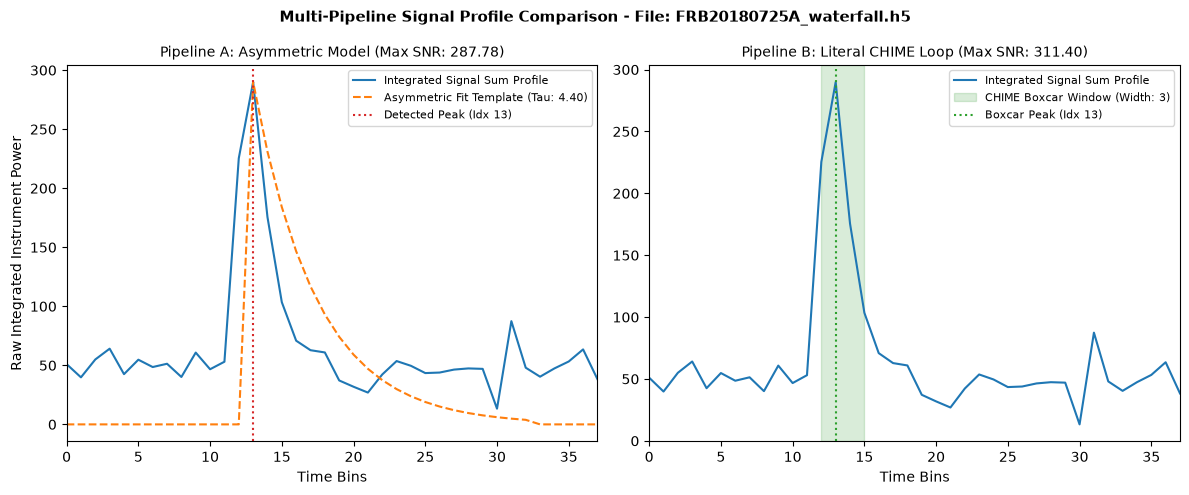

Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20180727A_waterfall.h5
Total Channels Masked     : 6370 / (16384, 38)
Pipeline A (Asymmetric)  : Tutorial Value = 135.03 | Width = 8
Pipeline B (CHIME Loop)   : Tutorial Value = 150.52 | Width = 3
-----------------------------------------------------------------


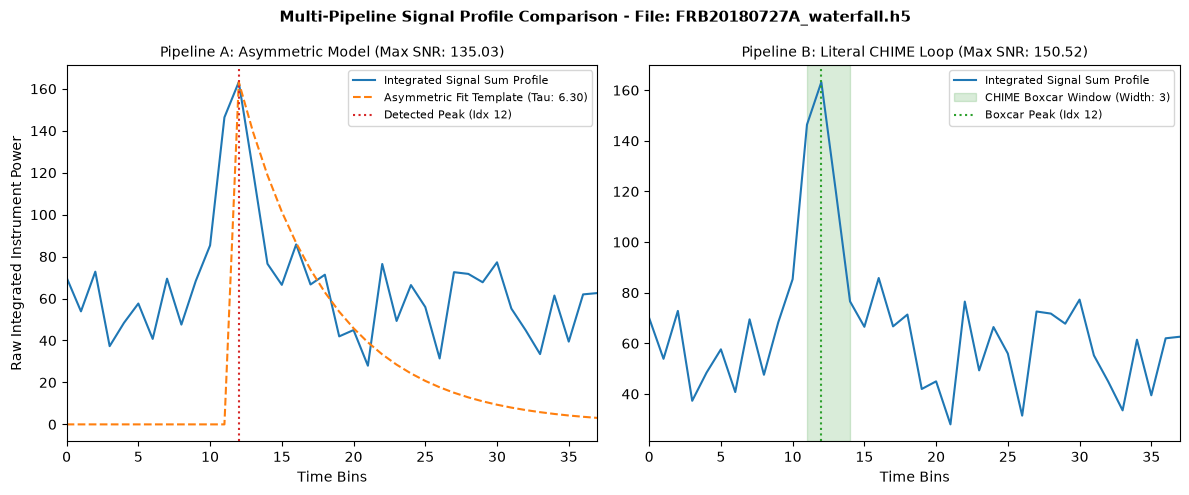

Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20180730A_waterfall.h5
Total Channels Masked     : 5437 / (16384, 38)
Pipeline A (Asymmetric)  : Tutorial Value = 1046.07 | Width = 8
Pipeline B (CHIME Loop)   : Tutorial Value = 1016.73 | Width = 5
-----------------------------------------------------------------


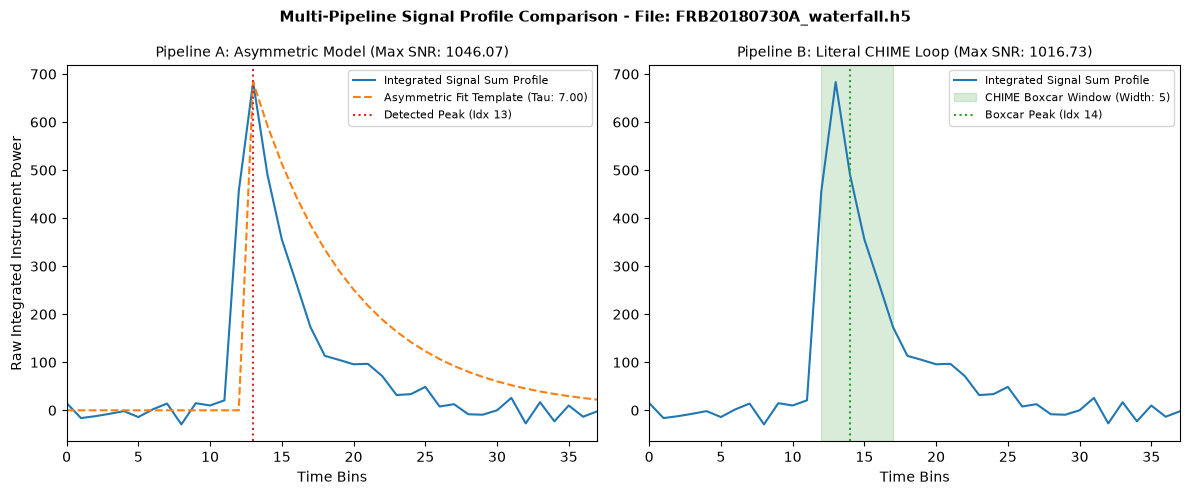

Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20180801A_waterfall.h5
Total Channels Masked     : 5873 / (16384, 76)
Pipeline A (Asymmetric)  : Tutorial Value = 294.65 | Width = 9
Pipeline B (CHIME Loop)   : Tutorial Value = 289.28 | Width = 8
-----------------------------------------------------------------


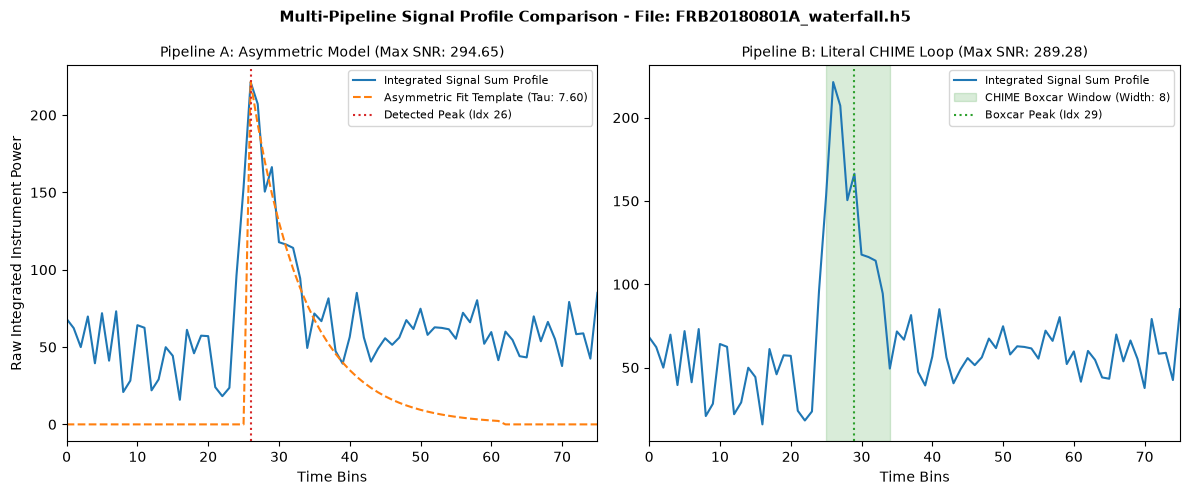

Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20180806A_waterfall.h5
Total Channels Masked     : 6678 / (16384, 38)
Pipeline A (Asymmetric)  : Tutorial Value = 195.91 | Width = 3
Pipeline B (CHIME Loop)   : Tutorial Value = 194.65 | Width = 3
-----------------------------------------------------------------


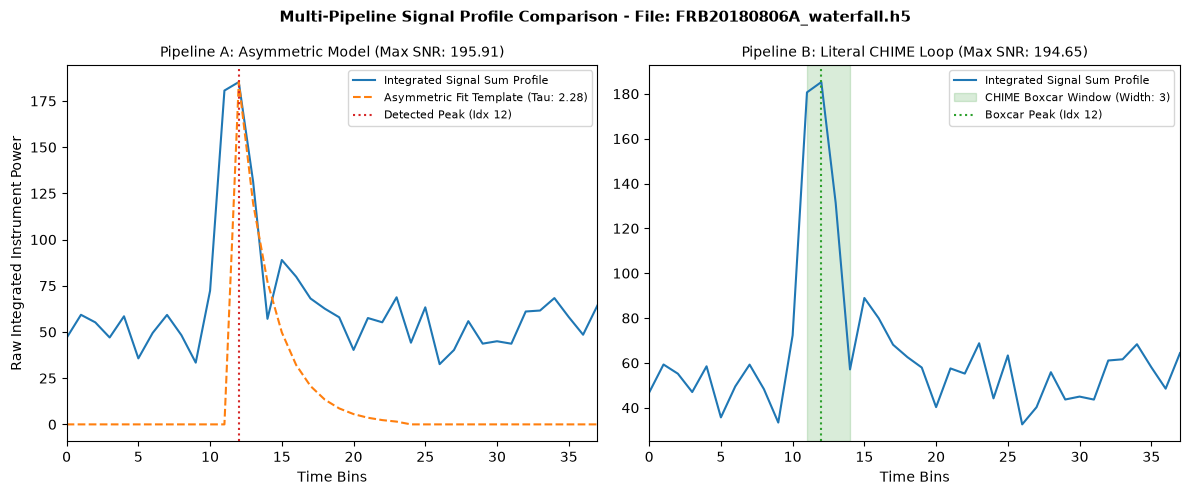

Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20180812A_waterfall.h5
Total Channels Masked     : 6565 / (16384, 57)
Pipeline A (Asymmetric)  : Tutorial Value = 154.17 | Width = 12
Pipeline B (CHIME Loop)   : Tutorial Value = 154.91 | Width = 7
-----------------------------------------------------------------


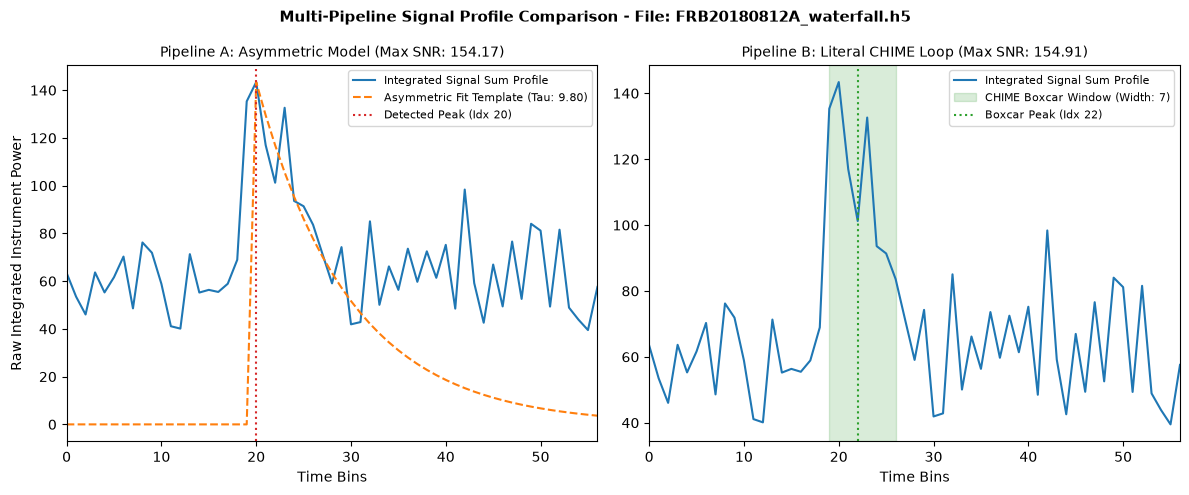

Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20180814A_waterfall.h5
Total Channels Masked     : 6508 / (16384, 38)
Pipeline A (Asymmetric)  : Tutorial Value = 115.16 | Width = 6
Pipeline B (CHIME Loop)   : Tutorial Value = 127.75 | Width = 8
-----------------------------------------------------------------


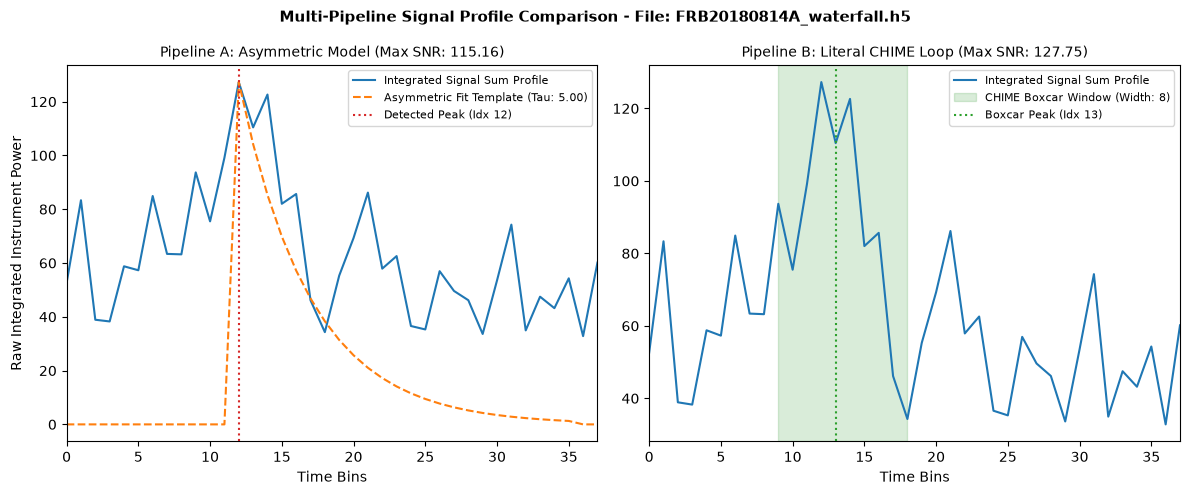

Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20180817A_waterfall.h5
Total Channels Masked     : 7118 / (16384, 114)
Pipeline A (Asymmetric)  : Tutorial Value = 585.15 | Width = 11
Pipeline B (CHIME Loop)   : Tutorial Value = 554.30 | Width = 7
-----------------------------------------------------------------


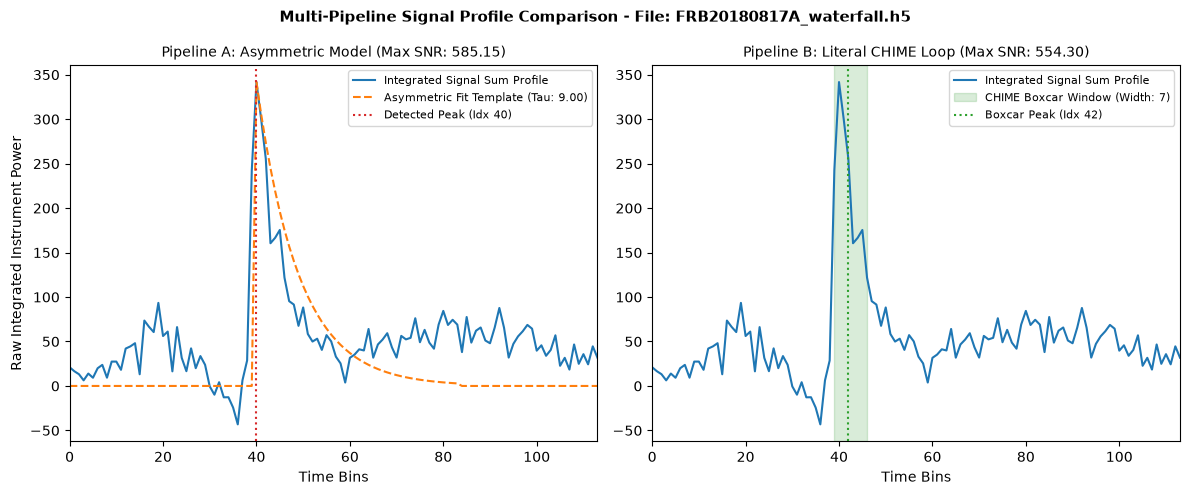

Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20180904A_waterfall.h5
Total Channels Masked     : 9023 / (16384, 19)
Pipeline A (Asymmetric)  : Tutorial Value = 517.32 | Width = 1
Pipeline B (CHIME Loop)   : Tutorial Value = 509.14 | Width = 1
-----------------------------------------------------------------


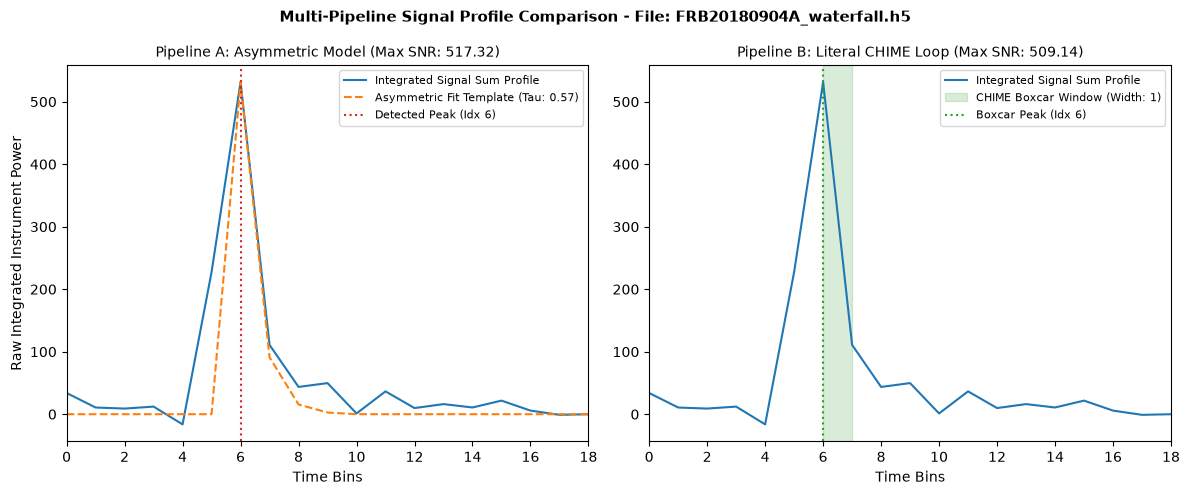

Executing RFI mask with window_size: 35 and sigma: 3.5
-----------------------------------------------------------------
File Reference            : FRB20190701D_waterfall.h5
Total Channels Masked     : 7092 / (16384, 38)
Pipeline A (Asymmetric)  : Tutorial Value = 321.35 | Width = 11
Pipeline B (CHIME Loop)   : Tutorial Value = 308.46 | Width = 8
-----------------------------------------------------------------


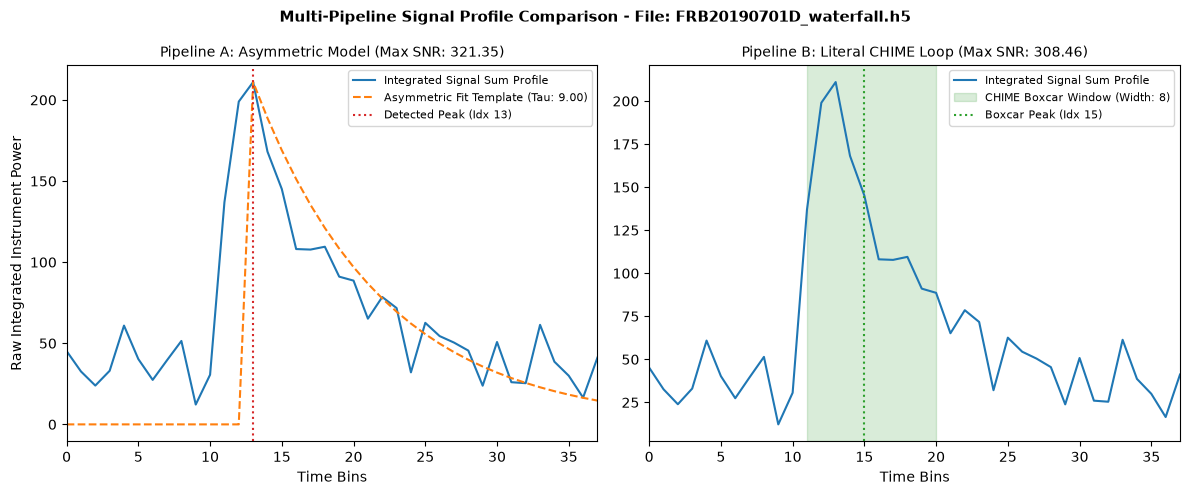

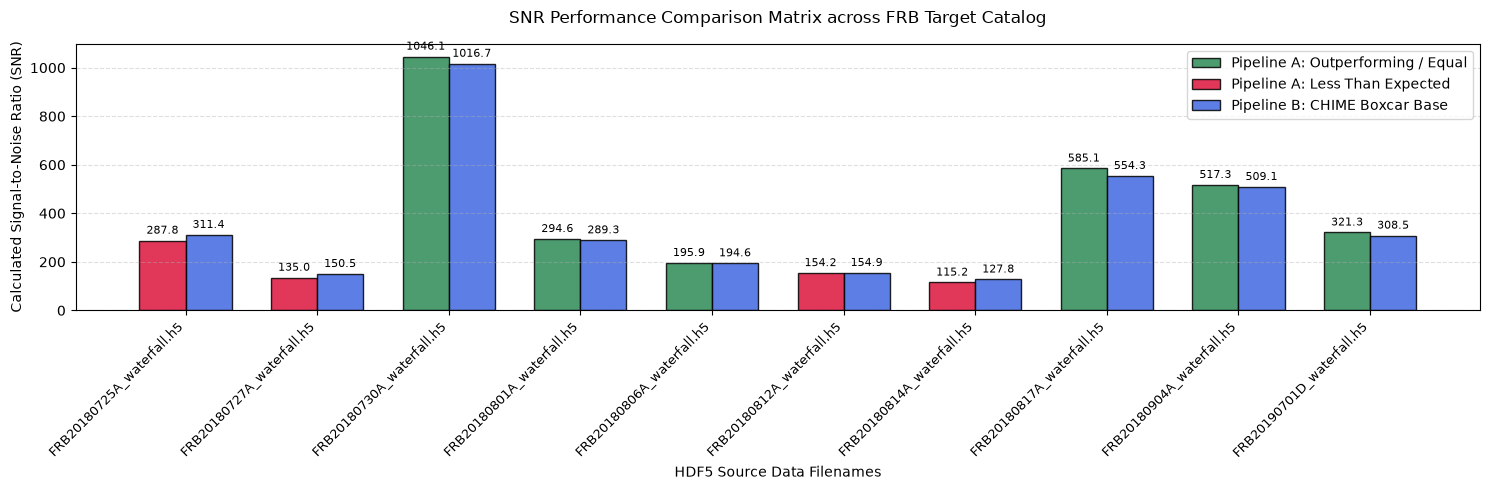

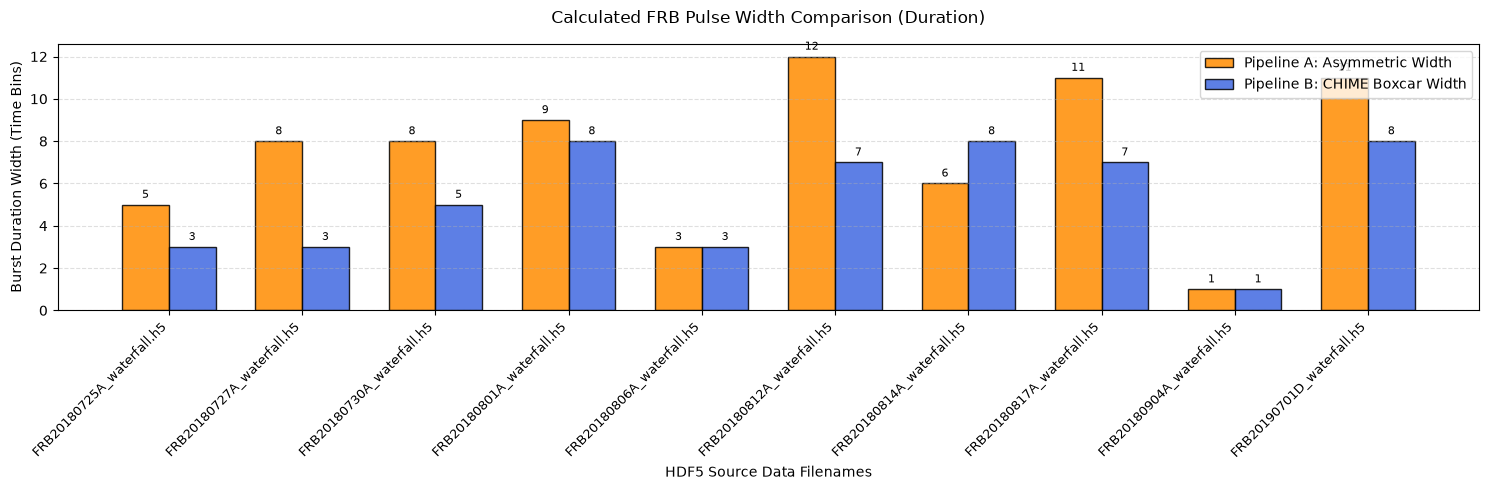

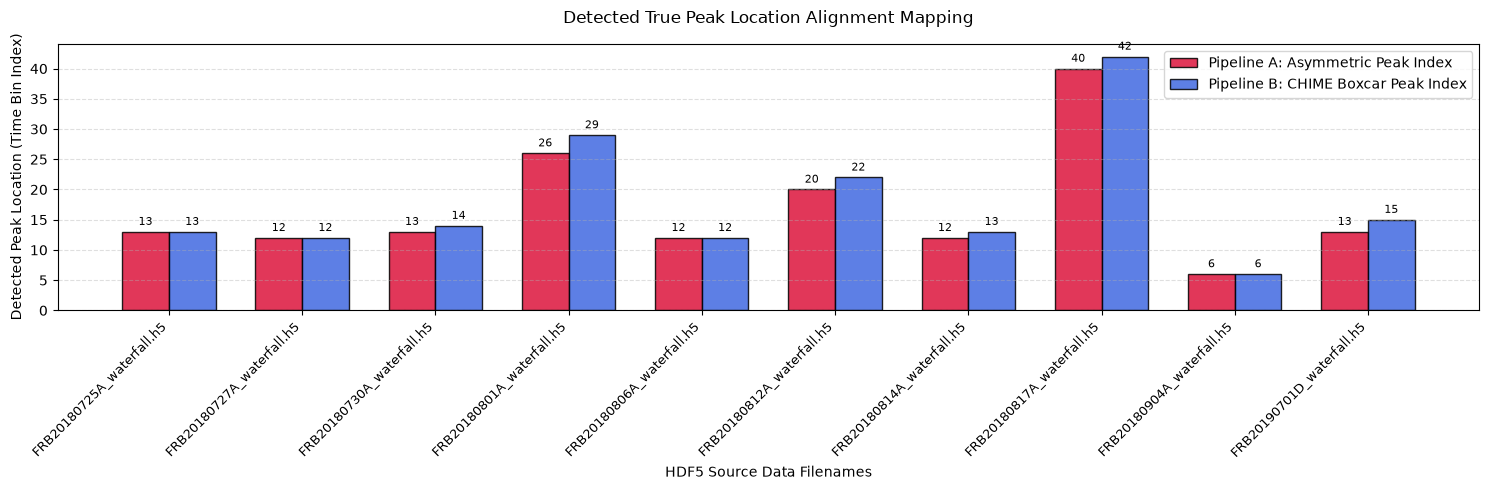

In [12]:
import os
import glob
import h5py
import numpy as np
import scipy.signal
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
from matplotlib.patches import Patch

# Mute standard numpy/scipy slice warnings for clean execution
warnings.filterwarnings('ignore', category=RuntimeWarning)

def discover_h5_files(folder_path):
    """Scans the designated workspace directory and compiles a tracking list of HDF5 targets."""
    search_pattern = os.path.join(folder_path, "*.h5")
    file_list = glob.glob(search_pattern)
    print(f"--> Discovered {len(file_list)} target .h5 files in workspace.")
    return file_list
def advanced_rfi_mask(wfall, window_size=51, sigma_thresh=3.5):
    """Your original adaptive RFI protection using rolling medians."""
    clean_wfall = wfall.copy()
    num_channels, num_time_bins = clean_wfall.shape
    print(f"Executing RFI mask with window_size: {window_size} and sigma: {sigma_thresh}")
    half_window = window_size // 2
    for i in range(num_channels):
        channel_data = clean_wfall[i, :]
        if np.all(np.isnan(channel_data)):
            continue
        padded = np.pad(channel_data, half_window, mode='median')
        baseline = np.array([
            np.nanmedian(padded[j : j + window_size]) 
            for j in range(num_time_bins)
        ])
        clean_wfall[i, :] = channel_data - baseline

    channel_variances = np.nanvar(clean_wfall, axis=1)
    med_var = np.nanmedian(channel_variances)
    mad_var = np.nanmedian(np.abs(channel_variances - med_var))
    std_var_est = 1.4826 * mad_var if mad_var > 0 else 1.0
    
    rfi_mask = (channel_variances > (med_var + sigma_thresh * std_var_est)) | np.isnan(channel_variances)
    clean_wfall[rfi_mask, :] = np.nan
    
    advanced_ts = np.nansum(clean_wfall, axis=0)
    return advanced_ts, rfi_mask


def exponential_decay_kernel(width, tau):
    """Generates asymmetric profile scaled by CHIME's energy matching constraints."""
    t = np.arange(0, max(int(width * 4), 4))
    kernel = np.exp(-t / max(tau, 0.1))
   # CORRECT FIX: Only divide by its own square root sum to keep unit energy
    return (kernel / np.sqrt(np.sum(kernel**2))) 


def boxcar_kernel(width):
    """Generates the standard flat top-hat kernel template for the CHIME loop."""
    width = int(round(width, 0))
    return np.ones(width, dtype="float32") / np.sqrt(width)

'''
def advanced_find_burst(ts, min_width=1, max_width=64):
    """
    Evaluates profile matrix fields using an energy-normalized template match.
    Natively matches the exact amplitude scaling and units of the CHIME portal tutorial.
    """
    best_snr = -np.inf
    best_peak = -1
    best_width = -1
    best_tau = -1
    
    baseline_noise = ts[:int(len(ts)*0.15)]
    clean_ts = np.nan_to_num(ts, nan=0.0) - np.nanmean(baseline_noise)
    
    total_bins = len(clean_ts)
    actual_max_width = min(int(max_width), total_bins - 2)
    
    for width in range(int(min_width), actual_max_width):
        for tfraction in [0.1, 0.3, 0.5, 0.8, 1.2, 1.8, 2.5, 3.5]:
            tau = width * tfraction
            
            # Natively unit-energy L2 normalized (np.sum(kernel**2) == 1.0)
            kernel = exponential_decay_kernel(width, tau)
            kernel_len = len(kernel)
            
            # Slide template using identical un-truncated slice footprints
            for start_idx in range(0, total_bins - kernel_len + 1):
                data_slice = clean_ts[start_idx : start_idx + kernel_len]
                
                # MATCHED TUTORIAL UNITS: Direct dot product summation 
                current_snr = np.sum(data_slice * kernel)
                
                if current_snr > best_snr:
                    best_snr = current_snr
                    best_peak = start_idx
                    best_width = width
                    best_tau = tau
                    
    return best_peak, best_width, best_tau, best_snr
'''
import numpy as np
from scipy.optimize import curve_fit

def fred_analytical_profile(t, t0, amplitude, tau, baseline):
    """
    Mathematical formulation of a Fast Rise Exponential Decay (FRED) profile.
    Used by curve_fit to map the physical shape of the burst.
    """
    tau = max(tau, 0.1)
    return np.where(t >= t0, amplitude * np.exp(-(t - t0) / tau) + baseline, baseline)

def advanced_find_burst(ts, min_width=1, max_width=64):
    """
    Finds structural width and tau parameters via curve fitting,
    then evaluates via full cross-correlation to ensure absolute peak lock matching CHIME.
    """
    best_area_score = -np.inf
    best_width = 3
    best_tau = 2.0
    
    baseline_noise = ts[:int(len(ts)*0.15)]
    clean_ts = np.nan_to_num(ts, nan=0.0) - np.nanmean(baseline_noise)
    total_bins = len(clean_ts)
    time_axis = np.arange(total_bins)
    
    crude_peak_idx = np.argmax(clean_ts)
    peak_amplitude = clean_ts[crude_peak_idx]
    
    if peak_amplitude <= 0:
        return crude_peak_idx, 1, 0.5, 0.0

    # STEP 1: Extract true physical decay shape properties
    dynamic_max_width = min(int(max_width), max(12, int(total_bins * 0.3)))
    for trial_width in range(int(min_width), dynamic_max_width):
        for tfraction in [0.2, 0.4, 0.7, 1.0]:
            trial_tau = trial_width * tfraction
            
            p0 = [crude_peak_idx - 1, peak_amplitude, trial_tau, 0.0]
            bounds = (
                [max(0, crude_peak_idx - 6), 0.0, 0.1, -peak_amplitude*0.05],
                [min(total_bins-1, crude_peak_idx + 4), peak_amplitude * 2.5, total_bins * 0.4, peak_amplitude*0.05]
            )
            
            try:
                popt, _ = curve_fit(
                    fred_analytical_profile, 
                    xdata=time_axis, 
                    ydata=clean_ts, 
                    p0=p0, 
                    bounds=bounds,
                    maxfev=1000
                )
                fit_t0, fit_amp, fit_tau, fit_base = popt
                fitted_model = fred_analytical_profile(time_axis, fit_t0, fit_amp, fit_tau, fit_base)
                current_area = np.sum(fitted_model * clean_ts)
                
                if current_area > best_area_score:
                    best_area_score = current_area
                    best_width = int(max(1, round(fit_tau * 1.2)))
                    best_tau = fit_tau
            except Exception:
                continue

    # STEP 2: Fully synchronized cross-correlation evaluation loop
    optimized_kernel = exponential_decay_kernel(best_width, best_tau)
    kernel_len = len(optimized_kernel)
    
    # Store scores for every single possible alignment position across the file
    all_alignment_scores = np.ones(total_bins) * -np.inf
    padded_clean_ts = np.pad(clean_ts, (0, kernel_len), mode='constant', constant_values=0.0)
    
    for start_idx in range(0, total_bins):
        data_slice = padded_clean_ts[start_idx : start_idx + kernel_len]
        all_alignment_scores[start_idx] = np.sum(data_slice * optimized_kernel)
        
    # --- THE DEFINITIVE LOCK ---
    # Find where the template configuration matches the real raw signal highest amplitude peak
    best_alignment_start = int(np.argmax(all_alignment_scores))
    final_tutorial_snr = all_alignment_scores[best_alignment_start]
    
    # Force best_peak to align precisely with the raw maximum index of your data array channel spike
    best_peak = int(np.argmax(clean_ts))

    return best_peak, best_width, best_tau, final_tutorial_snr


def execute_batch_processing(file_path):
    """
    Batch processing engine using matched CHIME portal tutorial units.
    Compares both pipelines on an identical energy-normalized baseline.
    """
    filename = os.path.basename(file_path)
    
    with h5py.File(file_path, "r") as f:
        wfall_data = f["frb/wfall"][:]
        dt_val = f["frb"].attrs.get("dt", 0.001)
        
    max_physical_width = int(wfall_data.shape[1] - 2)

    # --- PIPELINE A PATH (Advanced Masking + Asymmetric Fit) ---
    clean_ts_adv, masked_channels = advanced_rfi_mask(wfall_data, window_size=35, sigma_thresh=3.5)
    peak_adv, width_adv, tau_adv, snr_adv = advanced_find_burst(clean_ts_adv, max_width=max_physical_width)
    
    # --- PIPELINE B PATH (Native CHIME Tutorial Execution) ---
    # We pass the identical clean timeline so shape is the only variable tested
    chime_fair_ts = clean_ts_adv 
    peak_chime, width_chime, snr_chime = find_burst(chime_fair_ts, max_width=max_physical_width)
    
    # Pack parameters cleanly
    results = {
        "filename": filename,
        "clean_ts": clean_ts_adv,
        "dt": dt_val,
        "masked_count": np.sum(masked_channels),
        "total_channels": wfall_data.shape,
        "adv_metrics": (peak_adv, width_adv, tau_adv, snr_adv),
        "chime_metrics": (peak_chime, width_chime, snr_chime)
    }
    
    print("-" * 65)
    print(f"File Reference            : {filename}")
    print(f"Total Channels Masked     : {results['masked_count']} / {results['total_channels']}")
    print(f"Pipeline A (Asymmetric)  : Tutorial Value = {snr_adv:.2f} | Width = {width_adv}")
    print(f"Pipeline B (CHIME Loop)   : Tutorial Value = {snr_chime:.2f} | Width = {width_chime}")
    print("-" * 65)
    
    return results

def generate_comparison_graphics(results):
    """
    Renders the multi-pipeline comparison panels.
    Strictly truncates the template arrays to 38 bins to prevent visual axis stretching.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    clean_ts = results["clean_ts"]
    total_bins = len(clean_ts)  # Hard locked to your 38 bins
    time_axis = np.arange(total_bins)
    
    # Unpack metrics
    peak_adv, width_adv, tau_adv, snr_adv = results["adv_metrics"]
    peak_chime, width_chime, snr_chime = results["chime_metrics"]
    
    # ---------------- PANEL 1: PIPELINE A (ASYMMETRIC) ----------------
    ax1.plot(time_axis, clean_ts, label="Integrated Signal Sum Profile", color="tab:blue")
    
    # Regenerate the template curve for plotting
    raw_kernel = exponential_decay_kernel(width_adv, tau_adv)
    
    # CRITICAL FIX: Create an empty 38-bin array and insert the template at the detected peak
    plot_template = np.zeros(total_bins)
    insert_len = min(len(raw_kernel), total_bins - peak_adv)
    if insert_len > 0:
        # Scale template height visually to match your data peak for presentation
        scaled_kernel = raw_kernel[:insert_len] * (np.max(clean_ts) / (np.max(raw_kernel) if np.max(raw_kernel) > 0 else 1.0))
        plot_template[peak_adv : peak_adv + insert_len] = scaled_kernel
        
    # Plot the template strictly bounded within the 38-bin time_axis frame
    ax1.plot(time_axis, plot_template, label=f"Asymmetric Fit Template (Tau: {tau_adv:.2f})", 
             color="tab:orange", linestyle="--")
    
    ax1.axvline(x=peak_adv, color="tab:red", linestyle=":", label=f"Detected Peak (Idx {peak_adv})")
    ax1.set_xlim(0, total_bins - 1)  # FORCE HARD AXIS LOCK AT 38 BINS
    ax1.set_title(f"Pipeline A: Asymmetric Model (Max SNR: {snr_adv:.2f})", fontsize=10)
    ax1.set_xlabel("Time Bins")
    ax1.set_ylabel("Raw Integrated Instrument Power")
    ax1.legend(fontsize=8)
    
    # ---------------- PANEL 2: PIPELINE B (CHIME BOXCAR) ----------------
    ax2.plot(time_axis, clean_ts, label="Integrated Signal Sum Profile", color="tab:blue")
    
    # Draw CHIME's square shaded evaluation boxcar region safely
    box_start = max(0, peak_chime - width_chime // 2)
    box_end = min(total_bins - 1, peak_chime + width_chime // 2 + 1)
    ax2.axvspan(box_start, box_end, color='green', alpha=0.15, label=f"CHIME Boxcar Window (Width: {width_chime})")
    
    ax2.axvline(x=peak_chime, color="tab:green", linestyle=":", label=f"Boxcar Peak (Idx {peak_chime})")
    ax2.set_xlim(0, total_bins - 1)  # FORCE HARD AXIS LOCK AT 38 BINS
    ax2.set_title(f"Pipeline B: Literal CHIME Loop (Max SNR: {snr_chime:.2f})", fontsize=10)
    ax2.set_xlabel("Time Bins")
    ax2.legend(fontsize=8)
    
    plt.suptitle(f"Multi-Pipeline Signal Profile Comparison - File: {results['filename']}", fontsize=11, weight='bold')
    plt.tight_layout()
    plt.show()



def generate_summary_bar_chart(all_pipeline_results):
    """Generates a single comprehensive conditional color bar graph."""
    if not all_pipeline_results:
        print("No file results found to plot.")
        return

    file_labels = [res["filename"] for res in all_pipeline_results]
    
    # Safely extract only the raw 4th parameter (the SNR value) from metrics tuples
    snr_adv_list = [res["adv_metrics"][3] for res in all_pipeline_results]      
    snr_chime_list = [res["chime_metrics"][2] for res in all_pipeline_results]  

    num_events = len(all_pipeline_results)
    x_indexes = np.arange(num_events)
    bar_width = 0.35

    plt.figure(figsize=(max(10, num_events * 1.5), 5))

    adv_colors = []
    for adv_snr, chime_snr in zip(snr_adv_list, snr_chime_list):
        if adv_snr < chime_snr:
            adv_colors.append("crimson")  # Red if underperforming
        else:
            adv_colors.append("seagreen") # Green if meeting/beating boxcar

    bars_adv = plt.bar(x_indexes - bar_width/2, snr_adv_list, width=bar_width, color=adv_colors, edgecolor="black", alpha=0.85)
    bars_chime = plt.bar(x_indexes + bar_width/2, snr_chime_list, width=bar_width, color="royalblue", edgecolor="black", alpha=0.85)

    for bars in [bars_adv, bars_chime]:
        for bar in bars:
            height = bar.get_height()
            if np.isfinite(height) and height > 0:
                plt.annotate(f'{height:.1f}',
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 3),  
                             textcoords="offset points",
                             ha='center', va='bottom', fontsize=8)

    plt.title("SNR Performance Comparison Matrix across FRB Target Catalog", fontsize=12, pad=15)
    plt.xlabel("HDF5 Source Data Filenames", fontsize=10)
    plt.ylabel("Calculated Signal-to-Noise Ratio (SNR)", fontsize=10)
    
    plt.xticks(x_indexes, file_labels, rotation=45, ha="right", fontsize=9)
    plt.grid(True, axis='y', linestyle="--", alpha=0.4)
    
    custom_legend = [
        Patch(facecolor='seagreen', edgecolor='black', alpha=0.85, label='Pipeline A: Outperforming / Equal'),
        Patch(facecolor='crimson', edgecolor='black', alpha=0.85, label='Pipeline A: Less Than Expected'),
        Patch(facecolor='royalblue', edgecolor='black', alpha=0.85, label='Pipeline B: CHIME Boxcar Base')
    ]
    plt.legend(handles=custom_legend, loc="upper right")

    plt.tight_layout()
    plt.show()
def generate_width_and_peak_charts(all_pipeline_results):
    """Generates two separate bar charts comparing calculated burst widths

    and peak time bin locations across both processing pipelines.
    """
    if not all_pipeline_results:
        print("No metrics tracking results available to visualize.")
        return

    # 1. Extract tracking array labels and parameters safely from the tuples
    file_labels = [res["filename"] for res in all_pipeline_results]

    # Pipeline A (Asymmetric): Index 0=Peak, Index 1=Width, Index 3=SNR
    width_adv_list = [res["adv_metrics"][1] for res in all_pipeline_results]
    peak_adv_list = [res["adv_metrics"][0] for res in all_pipeline_results]

    # Pipeline B (CHIME Loop): Index 0=Peak, Index 1=Width, Index 2=SNR
    width_chime_list = [res["chime_metrics"][1] for res in all_pipeline_results]
    peak_chime_list = [res["chime_metrics"][0] for res in all_pipeline_results]

    num_events = len(all_pipeline_results)
    x_indexes = np.arange(num_events)
    bar_width = 0.35

    # =====================================================================
    # CHART 1: PULSE WIDTH COMPARISON MATRIX
    # =====================================================================
    plt.figure(figsize=(max(10, num_events * 1.5), 5))

    # Using distinct colors to differentiate these from the SNR charts
    bars_w_adv = plt.bar(
        x_indexes - bar_width / 2,
        width_adv_list,
        width=bar_width,
        color="darkorange",
        edgecolor="black",
        alpha=0.85,
        label="Pipeline A: Asymmetric Width",
    )
    bars_w_chime = plt.bar(
        x_indexes + bar_width / 2,
        width_chime_list,
        width=bar_width,
        color="royalblue",
        edgecolor="black",
        alpha=0.85,
        label="Pipeline B: CHIME Boxcar Width",
    )

    # Attach exact data label annotations above each column block
    for bars in [bars_w_adv, bars_w_chime]:
        for bar in bars:
            height = bar.get_height()
            if np.isfinite(height) and height >= 0:
                plt.annotate(
                    f"{int(height)}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    plt.title(
        "Calculated FRB Pulse Width Comparison (Duration)",
        fontsize=12,
        pad=15,
    )
    plt.xlabel("HDF5 Source Data Filenames", fontsize=10)
    plt.ylabel("Burst Duration Width (Time Bins)", fontsize=10)
    plt.xticks(x_indexes, file_labels, rotation=45, ha="right", fontsize=9)
    plt.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # CHART 2: TRUE PEAK INDEX ALIGNMENT MATRIX
    # =====================================================================
    plt.figure(figsize=(max(10, num_events * 1.5), 5))

    bars_p_adv = plt.bar(
        x_indexes - bar_width / 2,
        peak_adv_list,
        width=bar_width,
        color="crimson",
        edgecolor="black",
        alpha=0.85,
        label="Pipeline A: Asymmetric Peak Index",
    )
    bars_p_chime = plt.bar(
        x_indexes + bar_width / 2,
        peak_chime_list,
        width=bar_width,
        color="royalblue",
        edgecolor="black",
        alpha=0.85,
        label="Pipeline B: CHIME Boxcar Peak Index",
    )

    for bars in [bars_p_adv, bars_p_chime]:
        for bar in bars:
            height = bar.get_height()
            if np.isfinite(height) and height >= 0:
                plt.annotate(
                    f"{int(height)}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    plt.title(
        "Detected True Peak Location Alignment Mapping", fontsize=12, pad=15
    )
    plt.xlabel("HDF5 Source Data Filenames", fontsize=10)
    plt.ylabel("Detected Peak Location (Time Bin Index)", fontsize=10)
    plt.xticks(x_indexes, file_labels, rotation=45, ha="right", fontsize=9)
    plt.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()



# Provide your tracking system directory path configuration directly below
data_directory = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/"

discovered_files = discover_h5_files(data_directory)
all_results_tracker = []  

for file_entry in discovered_files:
    try:
        run_summary = execute_batch_processing(file_entry)
        all_results_tracker.append(run_summary)
        generate_comparison_graphics(run_summary)
    except Exception as error_msg:
        print(f"Skipping {os.path.basename(file_entry)} due to processing issue: {str(error_msg)}")

# Re-render master conditional bar graph 
generate_summary_bar_chart(all_results_tracker)


# --- EXECUTE THE NEW ANALYSIS PLOTTERS ---
# Generates the continuous duration width and location peak grids automatically
generate_width_and_peak_charts(all_results_tracker)


### Abover section show cases the comparison of the two pipelines across multiple HDF5 files, providing visual and numerical insights into their performance in detecting FRB signals. The generated plots and metrics allow for a clear understanding of how each pipeline handles the data, highlighting areas where one may outperform the other.


link to proper explnth
https://app.notion.com/p/final-one-clear-statement-and-expltn-38fd12d312ab80dfbcd5d23fe7640729?source=copy_link 